# Week 6 In-Class Exercise: Decision Trees

In the textbook (Chapter 6), we saw how a **Decision Tree** learns a flowchart of yes/no questions: at each node it picks the feature and threshold that best separates the classes (minimizing **Gini impurity** or **entropy**). Trees are easy to read, need no feature scaling, and can overfit badly if left unchecked.

In this exercise you'll apply those **same ideas** to two datasets that are new to this course, so the lessons show up clearly instead of being washed out by data that is too easy:

> **Breast Cancer Wisconsin** — 569 tumors, each described by 30 numeric measurements of a cell-nucleus image (radius, texture, concavity, ...). The label is **malignant** or **benign**. This is a real diagnostic problem with genuine difficulty, so different tree settings give genuinely different results.
>
> **Diabetes** — 442 patients, 10 baseline measurements (BMI, blood pressure, serum values, ...). The target is a **continuous** number: disease progression one year later. We'll use this for the *regression* tree.

Every technique from the textbook transfers directly — adapt the code, don't invent new methods.

1. Load and explore the data
2. Train and **visualize** a Decision Tree
3. Read **class probabilities** from a leaf
4. Control overfitting with **`max_depth`** (regularization)
5. Compare the **`gini`** and **`entropy`** split criteria
6. Read the tree's **feature importances**
7. See that trees have **high variance**
8. Fit a **Decision Tree Regressor** on the diabetes data

### Useful API References

| Task | Documentation |
|------|---------------|
| Load classification data | [load_breast_cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) |
| Load regression data | [load_diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html) |
| Train/test split | [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) |
| Tree classifier | [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) |
| Tree regressor | [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) |
| Draw a tree | [plot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) |
| Cross-validation | [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) |
| Metrics | [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) |

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/pjmcswee/IST707-Notebooks/blob/main/week6/week6_inclass_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## Setup

Run this cell to import the libraries and set the plotting defaults.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Step 1: Load the Data (Provided)

The textbook Chapter 6 demo used the iris flowers. Here we load the **Breast Cancer Wisconsin** dataset that ships with scikit-learn. This cell is provided — just run it.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer(as_frame=True)
X = cancer.data          # 30 numeric features
y = cancer.target        # 0 = malignant, 1 = benign
feature_names = list(cancer.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

counts = np.bincount(y)
print('Total samples:', X.shape[0], ' Features:', X.shape[1])
print('Classes:', [str(name) for name in cancer.target_names])
print('Class balance (full set): '
      f'{cancer.target_names[0]}={int(counts[0])}, '
      f'{cancer.target_names[1]}={int(counts[1])}')
print('Train:', X_train.shape[0], ' Test:', X_test.shape[0])
X.head()

Total samples: 569  Features: 30
Classes: ['malignant', 'benign']
Class balance (full set): malignant=212, benign=357
Train: 426  Test: 143


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 2: Train and Visualize a Decision Tree

A tree with no depth limit will grow until every leaf is pure. To *see* the logic, we start shallow. Train a `DecisionTreeClassifier(max_depth=3)` and draw it with `plot_tree`.

**Your turn!** Fit the tree on the training data, print train and test accuracy, and plot the tree.

**Hint (from the textbook):**
```python
from sklearn.tree import DecisionTreeClassifier, plot_tree
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)
plot_tree(tree_clf, feature_names=feature_names,
          class_names=cancer.target_names, filled=True, rounded=True)
```

Train acc: 0.9765258215962441
Test acc: 0.9440559440559441


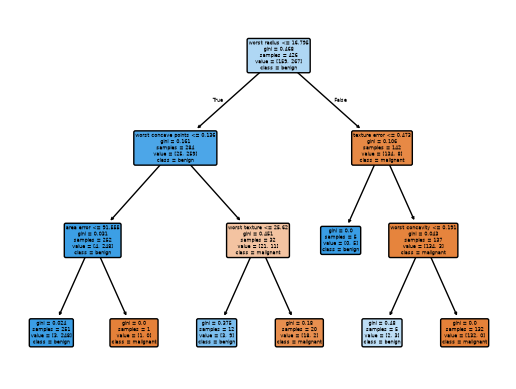

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
# TODO: Fit a DecisionTreeClassifier(max_depth=3) on the training data.
#       Print the train accuracy and the test accuracy.
#       Then draw the tree with plot_tree.
# Your code here:
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)
plot_tree(tree_clf, feature_names=feature_names,
          class_names=cancer.target_names, filled=True, rounded=True)

print('Train acc:', tree_clf.score(X_train, y_train))
print('Test acc:', tree_clf.score(X_test, y_test))

**Question:** Look at the very top node of the tree. Which single feature and threshold does the tree split on first? Why does it make sense that the tree considers this the most useful question to ask before any other?

*Your answer:* The first feature the tree splits on is worst radius with a threshold of 16.795. It makes sense that the tree considers this the most useful first question because it is looking at the size of the tumor. I believe that larger tumors are usually malignant.

## Step 3: Class Probabilities

A decision tree doesn't just output a label — each leaf holds the *proportion* of training samples of each class that landed there. `predict_proba` returns those proportions.

**Your turn!** Take the first 5 test samples and print, for each, the predicted class probabilities next to the predicted label and the true label.

**Hint (from the textbook):**
```python
tree_clf.predict_proba(X_test[:5]).round(3)
tree_clf.predict(X_test[:5])
```

In [11]:
# TODO: For the first 5 test samples, print the predicted probabilities,
#       the predicted class, and the true class.
# Your code here:
probas = tree_clf.predict_proba(X_test[:5]).round(3)
preds = tree_clf.predict(X_test[:5])

for i in range(len(probas)):
    print(f'Predicted probability: {probas[i]}; Predicted class: {preds[i]} ')
    print(f'True label: {y_test.iloc[i]}')


Predicted probability: [0.012 0.988]; Predicted class: 1 
True label: 1
Predicted probability: [1. 0.]; Predicted class: 0 
True label: 0
Predicted probability: [0.9 0.1]; Predicted class: 0 
True label: 1
Predicted probability: [0.012 0.988]; Predicted class: 1 
True label: 1
Predicted probability: [0.012 0.988]; Predicted class: 1 
True label: 0


**Question:** Some samples come back with a confident probability like 0.98, others with something closer to 0.7. Since every sample in the same leaf gets the *same* probability, what does a leaf with a 0.7 probability tell you about the training samples that fell into it?

*Your answer:*
A leaf with a 0.7 probability tells you that of the training samples that ended up in that leaf, 70% belonged to the predicted class and 30% to the other. The leaf is impure.

## Step 4: Regularization with `max_depth`

An unconstrained tree keeps splitting until the leaves are pure — memorizing the training set. `max_depth` is the main dial for controlling this. Too shallow **underfits**; too deep **overfits**.

**Your turn!** For `max_depth` in `[1, 2, 3, 4, 5, 8, 12, None]`, fit a tree and record both **train** and **test** accuracy. Then plot both curves against depth.

**Hint:**
```python
depths = [1, 2, 3, 4, 5, 8, 12, None]
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    # record accuracy_score on train and on test
```

 max_depth | Train Acc | Test Acc
----------------------------------
         1 |     0.923 |    0.923
         2 |     0.958 |    0.909
         3 |     0.977 |    0.944
         4 |     0.988 |    0.944
         5 |     0.995 |    0.937
         8 |     1.000 |    0.923
        12 |     1.000 |    0.923
      None |     1.000 |    0.923


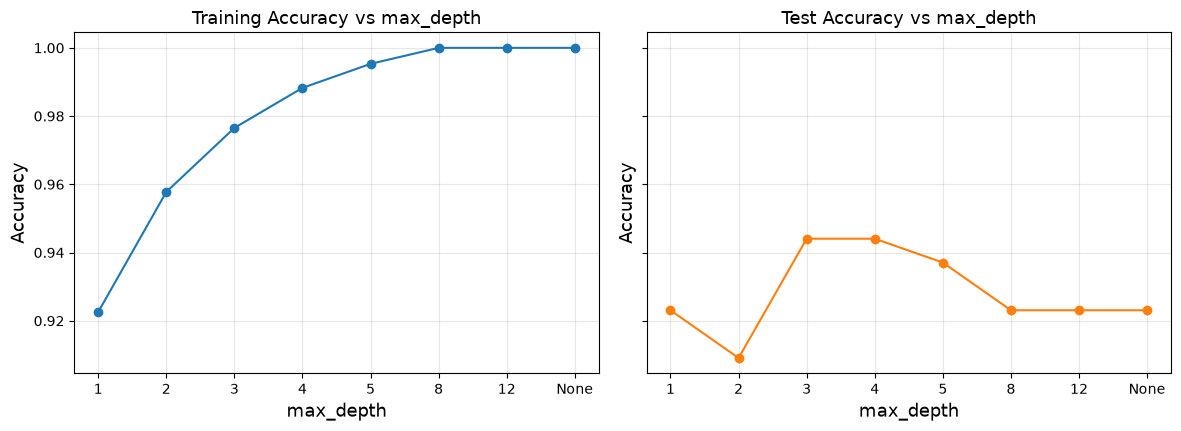

In [5]:
from sklearn.metrics import accuracy_score

# TODO: Sweep max_depth over [1, 2, 3, 4, 5, 8, 12, None].
#       Collect train accuracy and test accuracy for each.
#       Plot both curves vs depth and print the table.
# Your code here:

train_accuracies = []
test_accuracies = []

depths = [1, 2, 3, 4, 5, 8, 12, None]
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)

    training_preds = clf.predict(X_train)
    test_preds = clf.predict(X_test)

    train_accuracies.append(accuracy_score(y_train, training_preds))
    test_accuracies.append(accuracy_score(y_test, test_preds))

# Print the table
depth_labels = [str(d) for d in depths]
print(f"{'max_depth':>10} | {'Train Acc':>9} | {'Test Acc':>8}")
print('-' * 34)
for label, tr, te in zip(depth_labels, train_accuracies, test_accuracies):
    print(f'{label:>10} | {tr:>9.3f} | {te:>8.3f}')

# Plot train and test accuracy vs depth, side by side
x = range(len(depths))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

axes[0].plot(x, train_accuracies, 'o-', color='tab:blue')
axes[0].set_title('Training Accuracy vs max_depth')

axes[1].plot(x, test_accuracies, 'o-', color='tab:orange')
axes[1].set_title('Test Accuracy vs max_depth')

for ax in axes:
    ax.set_xticks(list(x))
    ax.set_xticklabels(depth_labels)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Question:** As `max_depth` grows, the train accuracy climbs all the way to 1.0 but the test accuracy peaks at a shallow depth and then *stops improving or drops*. Which depth would you pick, and what is the growing gap between the two curves telling you?

*Your answer:* I would pick an depth of 3 or 4 because the test accuracy plateaus there, and the training accuracy has not reached 100%. The growing gap between the two curves tells me that the model is overfit to the trianing data.

## Step 5: `gini` vs `entropy`

At each node the tree chooses the split that most reduces *impurity*. scikit-learn can measure impurity with **Gini** (the default) or **entropy** (information gain). They usually agree, but not always.

**Your turn!** Use `cross_val_score` (5-fold) on the training data to compare a tree built with `criterion='gini'` against one with `criterion='entropy'`. Print the mean CV accuracy of each.

**Hint:**
```python
from sklearn.model_selection import cross_val_score
for crit in ['gini', 'entropy']:
    scores = cross_val_score(
        DecisionTreeClassifier(criterion=crit, random_state=42),
        X_train, y_train, cv=5)
```

In [6]:
from sklearn.model_selection import cross_val_score

# TODO: Compare criterion='gini' vs criterion='entropy' with 5-fold
#       cross_val_score on the training set. Print each mean CV accuracy.
# Your code here:

for crit in ['gini', 'entropy']:
    scores = cross_val_score(
        DecisionTreeClassifier(criterion=crit, random_state=42),
        X_train, y_train, cv=5)
    
    print(f'Mean score for {crit}: {scores.mean():.4f}')


Mean score for gini: 0.9297
Mean score for entropy: 0.9554


**Question:** Did the two criteria give the same CV accuracy or different ones? Gini is the default mainly because it is slightly cheaper to compute. Based on what you see here, is the *choice of criterion* a big lever or a small one compared to `max_depth` from Step 4?

*Your answer:* Based on what I saw here, the choice of criterion is **not** as big of a lever as max_depth, the difference between the two was only about ~0.3.

## Step 6: Feature Importances

A trained tree can rank its features by how much each one reduced impurity across all its splits. This is one reason trees are prized for **interpretability**.

**Your turn!** Fit a `max_depth=4` tree, then plot a horizontal bar chart of the top 8 features by `feature_importances_`.

**Hint:**
```python
clf = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_train, y_train)
importances = clf.feature_importances_    # one value per feature, sums to 1
```

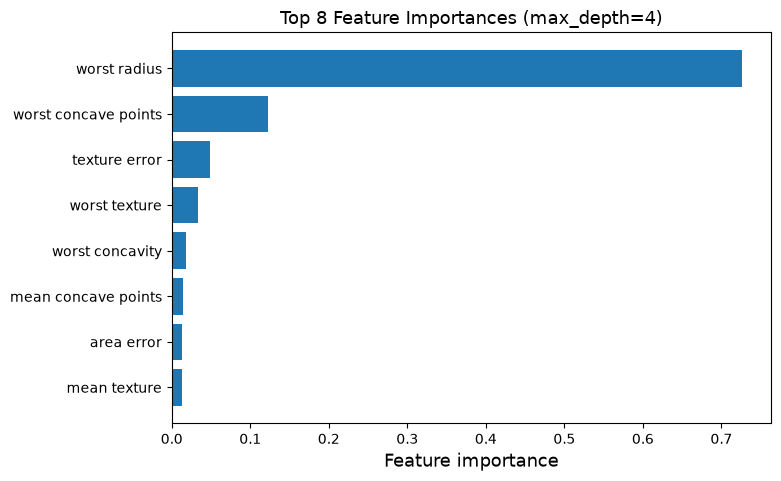

In [7]:
# TODO: Fit a max_depth=4 tree. Sort features by feature_importances_
#       and plot the top 8 as a horizontal bar chart.
# Your code here:

clf = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_train, y_train)
importances = clf.feature_importances_

# Top 8 features, sorted so the most important ends up at the top of the chart
top_idx = np.argsort(importances)[::-1][:8]
top_names = [feature_names[i] for i in top_idx][::-1]
top_values = importances[top_idx][::-1]

plt.figure(figsize=(8, 5))
plt.barh(top_names, top_values, color='tab:blue')
plt.xlabel('Feature importance')
plt.title('Top 8 Feature Importances (max_depth=4)')
plt.tight_layout()
plt.show()


**Question:** Most of the importance is concentrated in just a couple of features, while many of the 30 features get an importance of 0. What does an importance of 0 mean about how the tree used that feature? How could this ranking help a doctor or a data scientist who wants a simpler model?

*Your answer:* An importance of 0 means that the model did not use that feature. If a doctor or data scientist wanted a simpler model, they could exclude features with an importance of 0 and still end up with similar results.

## Step 7: Decision Trees Have High Variance

Trees are **unstable**: small changes in the training data can produce a very different tree. That instability is exactly why we later average many trees together in a Random Forest.

**Your turn!** Six times, draw a random 70% subsample of the training data, fit a `max_depth=3` tree, and record which feature it splits on *at the root*. Print the six root features.

**Hint:** the root split feature is `clf.tree_.feature[0]`, an index into `feature_names`.
```python
rng = np.random.RandomState(0)
idx = rng.choice(len(X_train), size=int(len(X_train) * 0.7), replace=False)
```

In [8]:
# TODO: Six times, subsample 70% of the training rows, fit a
#       max_depth=3 tree, and print the feature it splits on at the root
#       (feature_names[clf.tree_.feature[0]]).
# Your code here:

rng = np.random.RandomState(0)

for i in range(6):
    idx = rng.choice(len(X_train), size=int(len(X_train) * 0.7), replace=False)
    clf = DecisionTreeClassifier(max_depth=3, random_state=42).fit(
        X_train.iloc[idx], y_train.iloc[idx])
    print(f'Run {i + 1}: root feature = {feature_names[clf.tree_.feature[0]]}')




Run 1: root feature = worst radius
Run 2: root feature = worst concave points
Run 3: root feature = worst concave points
Run 4: root feature = worst radius
Run 5: root feature = worst radius
Run 6: root feature = worst perimeter


**Question:** Did every subsample pick the *same* root feature, or did the root change from run to run? Connect what you see to the term **high variance**, and explain in one sentence why averaging many such trees (a Random Forest) would help.

*Your answer:* The root changed from run to run. This model has high variance because it tries to fit the training data as close as possible, so when the data changes the model changes significantly. Average trees could help reduce variance by taking features that are most common among multiple trees.

## Step 8: A Regression Tree

Trees also do **regression**: instead of a class, each leaf predicts a *number* (the mean target of its training samples), which is why a regression tree's prediction looks like a **staircase**. We switch to the **diabetes** dataset and predict disease progression from a single feature, **BMI**, so we can see the staircase.

**Your turn!** Fit `DecisionTreeRegressor` at `max_depth` 2 and 5 on `bmi -> target`. Plot the data as a scatter and overlay each tree's prediction across the BMI range. Print the test RMSE for each depth.

**Hint (from the textbook):**
```python
from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor(max_depth=2, random_state=42).fit(X_bmi_train, y_train)
grid = np.linspace(bmi.min(), bmi.max(), 500).reshape(-1, 1)
y_line = reg.predict(grid)
```

max_depth=2: test RMSE = 64.73
max_depth=5: test RMSE = 65.65


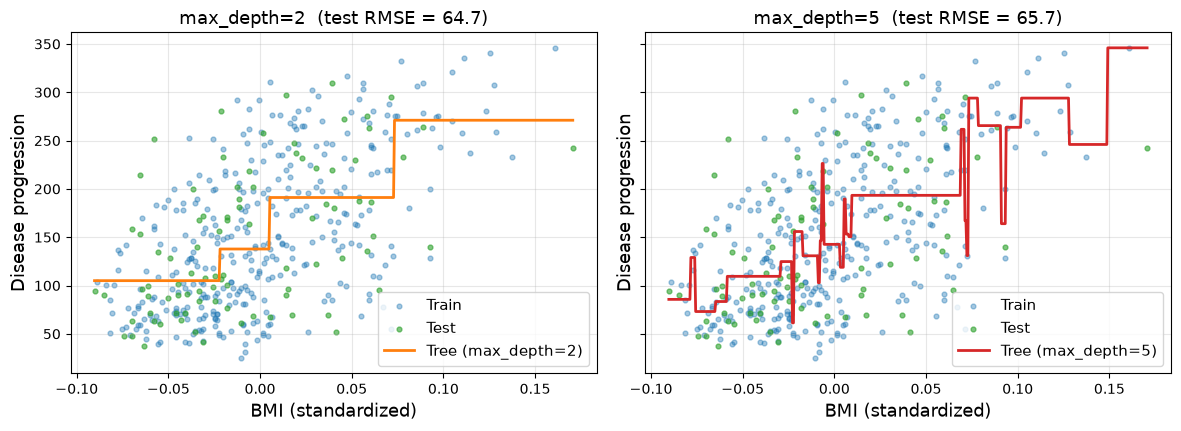

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import load_diabetes

# TODO: Load diabetes, use the single 'bmi' feature to predict the target.
#       Fit DecisionTreeRegressor at max_depth=2 and max_depth=5.
#       Scatter the test data and overlay each tree's staircase prediction.
#       Print the test RMSE for each depth.
# Your code here:

diabetes = load_diabetes(as_frame=True)
X_diabetes = diabetes.data   
y_diabetes = diabetes.target 

X_diabetes = X_diabetes[['bmi']]

bmi = X_diabetes

X_bmi_train, X_bmi_test, y_bmi_train, y_bmi_test = train_test_split(X_diabetes, y_diabetes, test_size = 0.2, random_state = 42)


from sklearn.metrics import mean_squared_error
import pandas as pd

# Evenly spaced BMI values across the full range, as a DataFrame so the column name matches
grid = pd.DataFrame({'bmi': np.linspace(bmi['bmi'].min(), bmi['bmi'].max(), 500)})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, d, color in zip(axes, [2, 5], ['tab:orange', 'tab:red']):
    reg = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_bmi_train, y_bmi_train)
    y_line = reg.predict(grid)

    rmse = np.sqrt(mean_squared_error(y_bmi_test, reg.predict(X_bmi_test)))
    print(f'max_depth={d}: test RMSE = {rmse:.2f}')

    ax.scatter(X_bmi_train['bmi'], y_bmi_train, s=12, alpha=0.4, color='tab:blue', label='Train')
    ax.scatter(X_bmi_test['bmi'], y_bmi_test, s=12, alpha=0.6, color='tab:green', label='Test')
    ax.plot(grid['bmi'], y_line, color=color, linewidth=2, label=f'Tree (max_depth={d})')
    ax.set_title(f'max_depth={d}  (test RMSE = {rmse:.1f})')
    ax.set_xlabel('BMI (standardized)')
    ax.set_ylabel('Disease progression')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


**Question:** The `max_depth=2` line is a coarse staircase with a few wide steps; the `max_depth=5` line has many narrow steps that wiggle to chase individual points. Which one is starting to overfit, and how do the two test RMSE values back up your answer?

*Your answer:* I think the max_depth 5 model is overfitting. The two test RMSE's back up my answer because RMSE increases as the depth increases, so a more complex model does worse on unseen data, which is a common sign of overiftting.

## Reflection Questions

Answer each question in the cell below it (1-3 sentences each).

**Q1:** A decision tree needs **no feature scaling**, while the SVMs and linear models from earlier weeks did. Looking at how a tree makes a split (a single `feature <= threshold` test), explain why scaling the features up or down doesn't change the tree it learns.

*Your answer:* Feature scaling does not change how a tree learns because at each split, the tree only looks at one feature. So it does not matter if one feature has significantly higher or lower values than otehr features since it is looked at in isolation. The problem with unscaled featuresd in SVMs and linear models is that features with very large values COMAPRED to other features could be misinterpreted by the model as being more important. Since each split in a decision tree only looks at one feature, it doesn't matter how each feature compares to one another.

**Q2:** In Step 4 you saw a deep tree hit 100% train accuracy. Why is 100% training accuracy *not* something to celebrate, and which number were you actually watching to judge the model?

*Your answer:* A 100% training accuracy is not something to celebrate because that means the model fits the training data perfectly, meaning it is overfit and will not generalize well to new data. The metric I was actually watching to judge the data was the testing accuracy because that tells me how well the model is able to perform on unseen data.

**Q3:** Trees split on one feature at a time, producing decision boundaries made of horizontal and vertical lines. What kind of true boundary (think of a diagonal separation between two classes) would force a tree to use many awkward steps to approximate it?

*Your answer:* I true boundary that is diagnol to the axis, or a boundary where the classes essentially overlap and would need a curved line to seperate them would force the tree to use many awkward steps to approximate it.

**Q4:** Step 7 showed that a single tree is high-variance. Briefly describe how a **Random Forest** (next week's topic) uses many trees to turn that weakness into a strength.

*Your answer:* A random forest model averages the predictions of many decision trees. The high variance of the single trees turns into a strength of random forest because each individual tree can fit it's subset of the data well, borderline overfitting, but since it is averaged out with many other trees that fit their own subset of data strongly, the final model of the random forest is accurate and not overfit.